# Forward rate agreements

Connect a forward borrowing rate to the sign and settlement of an FRA.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

An FRA isolates interest on one future borrowing period. The buyer in this chapter receives floating and pays fixed, so a realized fixing above the agreed strike creates a positive settlement amount.

For dates $T_1,T_2$ and accrual $\tau$, the simple projection-implied forward is $L=[P^{proj}(T_1)/P^{proj}(T_2)-1]/\tau$. An end-paid linear interest difference is $N\tau(L-K)$. The standard start-paid FRA transforms that amount into $N\tau(L-K)/(1+\tau L)$ using the observed fixing at $T_1$.

The exercise uses a period from six to nine months after the reference date, notional 100 and Actual/360 accrual. It computes the forward from the illustrative projection curve and compares strikes 50 bp below, at and above it. Under the explicitly deterministic rate-path assumption, it discounts the start settlement with the OIS discount factor to show its current value. The at-forward contract is zero and buyer/seller signs are opposite.

The division by $1+\tau L$ makes start settlement nonlinear in the future fixing. Treating $L$ as a known path value here is an analytical illustration; in a stochastic multi-curve model, replacing that fixing by one simple forward does not by itself price the expectation or settlement convexity. Futures/FRA convexity adjustments, historical fixings, broken dates and actual contract settlement conventions are not estimated.

The chapter therefore teaches rate/strike direction and settlement mechanics without claiming a production FRA engine. Its period and currency conventions are declared rather than inherited from an unrelated index.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
with valuation_date():
    discount,projection,_=curves()
    start=CAL.advance(DATE,ql.Period(6,ql.Months))
    end=CAL.advance(DATE,ql.Period(9,ql.Months))
    tau=ql.Actual360().yearFraction(start,end)
    forward=(projection.discount(start)/projection.discount(end)-1)/tau
    rows=[]
    for spread in [-.005,0,.005]:
        strike=forward+spread
        terminal=100*tau*(forward-strike)
        settlement=terminal/(1+tau*forward)
        rows.append({'strike_pct':strike*100,'forward_pct':forward*100,'end_interest_difference':terminal,'start_settlement':settlement,'deterministic_start_PV':discount.discount(start)*settlement})
fra=pd.DataFrame(rows)
assert abs(fra.iloc[1].deterministic_start_PV)<1e-12
assert fra.iloc[0].start_settlement>0>fra.iloc[2].start_settlement
assert np.allclose(fra.start_settlement*(1+tau*forward),fra.end_interest_difference)
print(f'Accrual {start.ISO()} to {end.ISO()}; Actual/360 fraction {tau:.6f}')
display(fra.round(6))

Accrual 2027-03-15 to 2027-06-15; Actual/360 fraction 0.255556


,strike_pct,forward_pct,end_interest_difference,start_settlement,deterministic_start_PV
0,3.739421,4.239421,0.127778,0.126408,0.124061
1,4.239421,4.239421,0.000000,0.000000,0.000000
2,4.739421,4.239421,-0.127778,-0.126408,-0.124061


## Economic relationship

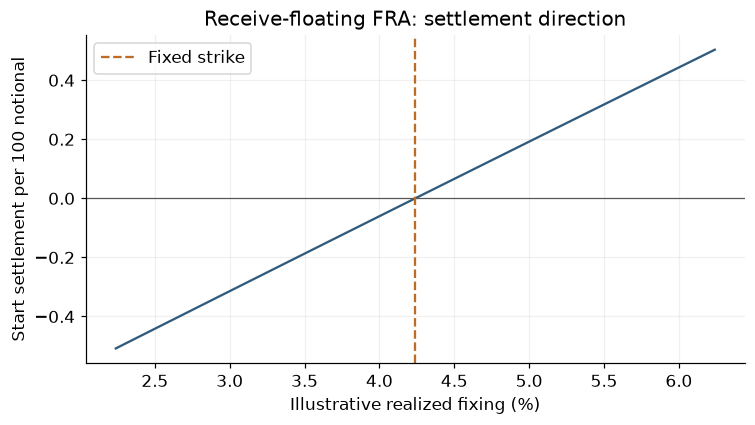

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
fixings=np.linspace(max(-.01,forward-.02),forward+.02,80)
settlement=100*tau*(fixings-forward)/(1+tau*fixings)
ax.plot(100*fixings,settlement,color='#315b7d');ax.axhline(0,color='#555555',lw=.8)
ax.axvline(100*forward,color='#bc6c25',ls='--',label='Fixed strike')
ax.set(xlabel='Illustrative realized fixing (%)',ylabel='Start settlement per 100 notional',title='Receive-floating FRA: settlement direction')
ax.legend();fig.tight_layout();plt.show()

## Interpretation

At the projected forward, the deterministic FRA has zero settlement value. A higher fixing benefits the receive-floating party. Start settlement differs from an end-paid interest difference and needs an explicit convention.